In [28]:
# Celda 1: Importaciones
import json
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import re  # Para expresiones regulares


In [29]:
# Celda 2: Cargar datos y agrupar por video_url
# Load the data from excel 
df = pd.read_excel('C:\\Users\\sandr\\Documents\\scrp_tiktok_tfg\\analysis\\nlp\\products and brands detection\\resultados_finales.xlsx')

# Agrupar por 'video_url' y consolidar las listas en cada grupo
df_grouped = df.groupby('video_url').agg({
    'mentioned_brands': lambda x: list(set(sum([eval(i) for i in x if isinstance(i, str)], []))),
}).reset_index()

ruta_destino = r'C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\resultados_agrupados.xlsx'
df_grouped.to_excel(ruta_destino, index=False)
print(f'Archivo guardado en: {ruta_destino}')

df_transactions = df_grouped

Archivo guardado en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\resultados_agrupados.xlsx


In [30]:
# Celda 3: Cargar JSON y datos agrupados
# CARGAR JSON Y EXCEL AGRUPADO 
json_file_path = r"C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\products and brands detection\all_brands_products.json"
excel_file_path = r"C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\resultados_agrupados.xlsx"

with open(json_file_path, 'r', encoding='utf-8') as file:
    brands_products = json.load(file)

# Extraer nombres de las marcas del JSON
brand_names = list(brands_products.keys())
print(f"Total de marcas encontradas en el JSON: {len(brand_names)}")

# Cargar Excel
df_transactions = pd.read_excel(excel_file_path)
print(f"Datos cargados del Excel. Forma: {df_transactions.shape}")
print(f"Columnas: {df_transactions.columns.tolist()}")

# Normalizar marcas (unificar nombres que pueden dar discrepancias)
brand_normalization = {
    "HUDA BEAUTY": "Huda Beauty",
    "Huda Beauty": "Huda Beauty",
    "DIOR": "Dior Beauty",
    "Dior Beauty": "Dior Beauty",
    "Rare Beauty by Selena Gomez": "Rare Beauty",
    "Rare Beauty": "Rare Beauty",
    "MAKEUP BY MARIO": "MAKEUP BY MARIO",
    "tarte": "tarte",
    "Tarte": "tarte"
}

Total de marcas encontradas en el JSON: 147
Datos cargados del Excel. Forma: (183, 2)
Columnas: ['video_url', 'mentioned_brands']


In [31]:
# Celda 4: Procesar transacciones
def extract_brands(brands_text):
    if not isinstance(brands_text, str):
        return []
    # Formato del excel es [marca1, marca2, ...]
    # 1. Eliminar corchetes
    brands_text = brands_text.strip('[]')
    # 2. Dividir por comas, pero con cuidado de los nombres con comas
    brands = []
    # Patrón regrex para capturar nombres entre comillas o sin comillas
    pattern = r"'([^']+)'|\\\"([^\\\"]+)\\\"|([^,]+)"
    for match in re.finditer(pattern, brands_text):
        brand = next((g for g in match.groups() if g is not None), None)
        if brand:
            brand = brand.strip()
            if brand: 
                brands.append(brand)
    return brands

# Obtener las transacciones del DataFrame
transactions = []

for index, row in df_transactions.iterrows():
    brands_list = extract_brands(row['mentioned_brands'])
    if brands_list: 
        transactions.append(brands_list)
print(f"Total de transacciones procesadas: {len(transactions)}")

# Normalizar los nombres de las marcas
normalized_transactions = []
for transaction in transactions:
    normalized_transaction = []
    for brand in transaction:
        # Eliminar comillas y espacios en blanco
        brand = brand.strip("'\" ")
        # Normalizar con el diccionario
        normalized_brand = brand_normalization.get(brand, brand)
        normalized_transaction.append(normalized_brand)
    # Eliminar duplicados de la misma transacción
    normalized_transaction = list(set(normalized_transaction))
    if normalized_transaction: 
        normalized_transactions.append(normalized_transaction)

Total de transacciones procesadas: 183


In [32]:
# Celda 5: Análisis de frecuencia de marcas
# Frecuencia de cada marca
brand_counts = {}
for transaction in normalized_transactions:
    for brand in transaction:
        brand_counts[brand] = brand_counts.get(brand, 0) + 1

# Marcas más frecuentes
top_brands = sorted(brand_counts.items(), key=lambda x: x[1], reverse=True)[:15]
print("\nTop 15 marcas más frecuentes:")
for brand, count in top_brands:
    print(f"{brand}: {count} menciones")


Top 15 marcas más frecuentes:
Charlotte Tilbury: 114 menciones
Rare Beauty: 64 menciones
Drunk Elephant: 63 menciones
Dior Beauty: 52 menciones
Fenty Beauty: 46 menciones
Huda Beauty: 45 menciones
NARS: 39 menciones
Hourglass: 37 menciones
PATRICK TA: 36 menciones
Benefit Cosmetics: 36 menciones
Anastasia Beverly Hills: 27 menciones
Sol de Janeiro: 26 menciones
tarte: 26 menciones
MAKEUP BY MARIO: 26 menciones
Too Faced: 24 menciones


In [33]:
# Celda 6: Generar conjuntos frecuentes con apriori
# Convertir las transacciones a formato binario usando TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(normalized_transactions).transform(normalized_transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Ajustar el min_support - empezar con un valor mayor y reducir si es necesario
min_support_values = [0.05, 0.03, 0.02, 0.01, 0.005]  # Lista de valores a probar
frequent_itemsets = None

for min_support_value in min_support_values:
    print(f"\nBuscando conjuntos de ítems frecuentes con min_support = {min_support_value}...")
    try:
        frequent_itemsets = apriori(df, min_support=min_support_value, use_colnames=True)
        if len(frequent_itemsets) > 0:
            print(f"Se encontraron {len(frequent_itemsets)} conjuntos de ítems frecuentes.")
            break
    except Exception as e:
        print(f"Error con min_support={min_support_value}: {e}")

if frequent_itemsets is None or len(frequent_itemsets) == 0:
    print("No se pudieron encontrar conjuntos de ítems frecuentes. Usando el valor mínimo de soporte.")
    min_support_value = min(min_support_values)
    try:
        frequent_itemsets = apriori(df, min_support=min_support_value, use_colnames=True)
    except Exception as e:
        print(f"Error final: {e}")
        exit(1)

print(f"Conjuntos de ítems frecuentes encontrados: {len(frequent_itemsets)}")
if len(frequent_itemsets) > 0:
    print(frequent_itemsets.head())



Buscando conjuntos de ítems frecuentes con min_support = 0.05...
Se encontraron 116 conjuntos de ítems frecuentes.
Conjuntos de ítems frecuentes encontrados: 116
    support                   itemsets
0  0.147541  (Anastasia Beverly Hills)
1  0.196721        (Benefit Cosmetics)
2  0.076503              (Bobbi Brown)
3  0.622951        (Charlotte Tilbury)
4  0.076503                      (DUO)


In [34]:
# Celda 7: Generar reglas de asociación
# Generar reglas de asociación
rules = None
if len(frequent_itemsets) > 0:
    try:
        # Filtrar itemsets con más de un elemento para las reglas
        frequent_itemsets_for_rules = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1)]
        
        if len(frequent_itemsets_for_rules) > 0:
            # Utilizar support_only=True para evitar el error con conjuntos que no pueden generar reglas
            rules = association_rules(frequent_itemsets_for_rules, metric="lift", min_threshold=1, support_only=True)
            print(f"\nReglas de asociación generadas: {len(rules)}")
            if len(rules) > 0:
                print(rules.head())
            else:
                print("No se generaron reglas de asociación con el umbral especificado.")
        else:
            print("No hay conjuntos de ítems con más de un elemento para generar reglas.")
    except Exception as e:
        print(f"Error al generar reglas: {e}")
        # Intentar de nuevo con support_only si falló el primer intento
        try:
            print("Intentando generar reglas con support_only=True...")
            rules = association_rules(frequent_itemsets_for_rules, metric="lift", min_threshold=1, support_only=True)
            print(f"Reglas generadas en segundo intento: {len(rules)}")
        except Exception as e2:
            print(f"Error en segundo intento: {e2}")

# Si no se encontraron reglas, crear un DataFrame vacío
if rules is None:
    rules = pd.DataFrame(columns=['antecedents', 'consequents', 'antecedent support', 
                                  'consequent support', 'support', 'confidence', 'lift', 
                                  'leverage', 'conviction'])



Reglas de asociación generadas: 0
No se generaron reglas de asociación con el umbral especificado.


In [35]:
# Celda 8: Crear carpeta para resultados y guardar frecuencia de marcas
# Crear carpeta para guardar resultados si no existe
results_dir = r"C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results"
os.makedirs(results_dir, exist_ok=True)

# Guardar los resultados de análisis de frecuencia de marcas
brand_freq_df = pd.DataFrame(brand_counts.items(), columns=['Brand', 'Frequency'])
brand_freq_df = brand_freq_df.sort_values('Frequency', ascending=False)
brand_freq_file = os.path.join(results_dir, "brand_frequencies.csv")
brand_freq_df.to_csv(brand_freq_file, index=False)
print(f"\nFrecuencias de marcas guardadas en: {brand_freq_file}")

# Guardar frequent_itemsets en CSV
if frequent_itemsets is not None and len(frequent_itemsets) > 0:
    # Convertir los frozensets a strings para guardar
    frequent_itemsets_df = frequent_itemsets.copy()
    frequent_itemsets_df['itemsets_str'] = frequent_itemsets_df['itemsets'].apply(lambda x: ', '.join(list(x)))
    itemsets_file = os.path.join(results_dir, "frequent_itemsets.csv")
    frequent_itemsets_df.to_csv(itemsets_file, index=False)
    print(f"Conjuntos de ítems frecuentes guardados en: {itemsets_file}")

# Guardar reglas en CSV si existen
if len(rules) > 0:
    # Convertir frozensets a strings para guardar
    rules_df = rules.copy()
    rules_df['antecedents_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['consequents_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    rules_file = os.path.join(results_dir, "association_rules.csv")
    rules_df.to_csv(rules_file, index=False)
    print(f"Reglas guardadas en: {rules_file}")


Frecuencias de marcas guardadas en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\brand_frequencies.csv
Conjuntos de ítems frecuentes guardados en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\frequent_itemsets.csv


Gráfico de frecuencia de marcas guardado en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\top_brands_frequency.png


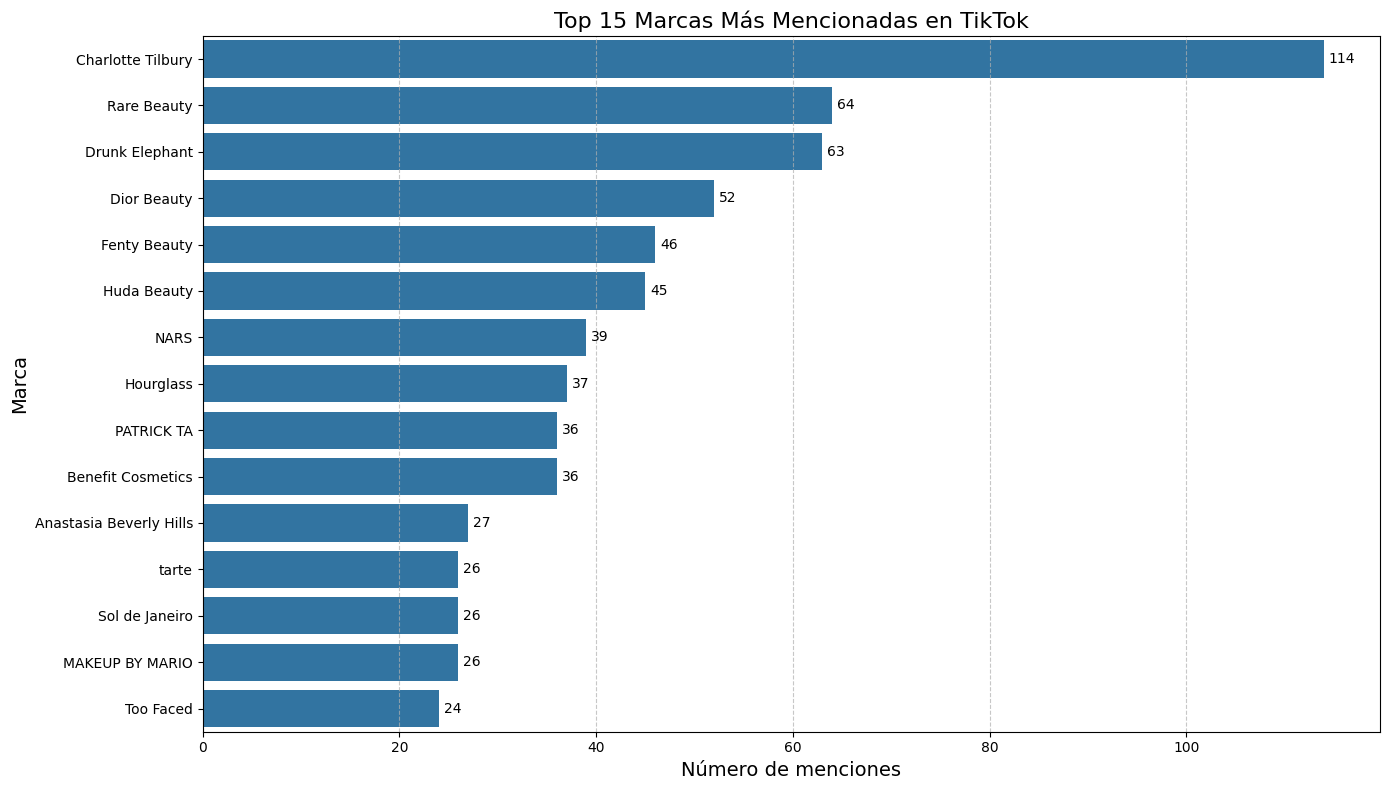

In [36]:
# Celda 9: Crear gráfico de barras para las principales marcas
plt.figure(figsize=(14, 8))
top_n = 15
top_brands_df = brand_freq_df.head(top_n)
ax = sns.barplot(x='Frequency', y='Brand', data=top_brands_df)
plt.title(f'Top {top_n} Marcas Más Mencionadas en TikTok', fontsize=16)
plt.xlabel('Número de menciones', fontsize=14)
plt.ylabel('Marca', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir valores en las barras
for i, v in enumerate(top_brands_df['Frequency']):
    ax.text(v + 0.5, i, str(v), va='center')

brands_chart_file = os.path.join(results_dir, "top_brands_frequency.png")
plt.tight_layout()
plt.savefig(brands_chart_file, dpi=300)
print(f"Gráfico de frecuencia de marcas guardado en: {brands_chart_file}")

In [37]:
# Celda 10: Crear matriz de co-ocurrencia con TODAS las marcas
# Obtener la lista completa de marcas
all_brands_list = list(brand_counts.keys())
cooccurrence_matrix = np.zeros((len(all_brands_list), len(all_brands_list)))

for i, brand1 in enumerate(all_brands_list):
    for j, brand2 in enumerate(all_brands_list):
        if i != j:
            # Contar cuántas veces aparecen juntas las marcas
            cooccurrence = 0
            for transaction in normalized_transactions:
                if brand1 in transaction and brand2 in transaction:
                    cooccurrence += 1
            cooccurrence_matrix[i, j] = cooccurrence

# Crear DataFrame para el mapa de calor
cooccurrence_df = pd.DataFrame(cooccurrence_matrix, index=all_brands_list, columns=all_brands_list)

# Guardar matriz de co-ocurrencia
cooccurrence_file = os.path.join(results_dir, "brand_cooccurrence_matrix.csv")
cooccurrence_df.to_csv(cooccurrence_file)
print(f"Matriz de co-ocurrencia guardada en: {cooccurrence_file}")

Matriz de co-ocurrencia guardada en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\brand_cooccurrence_matrix.csv


Mapa de calor guardado en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\brands_cooccurrence_heatmap.png


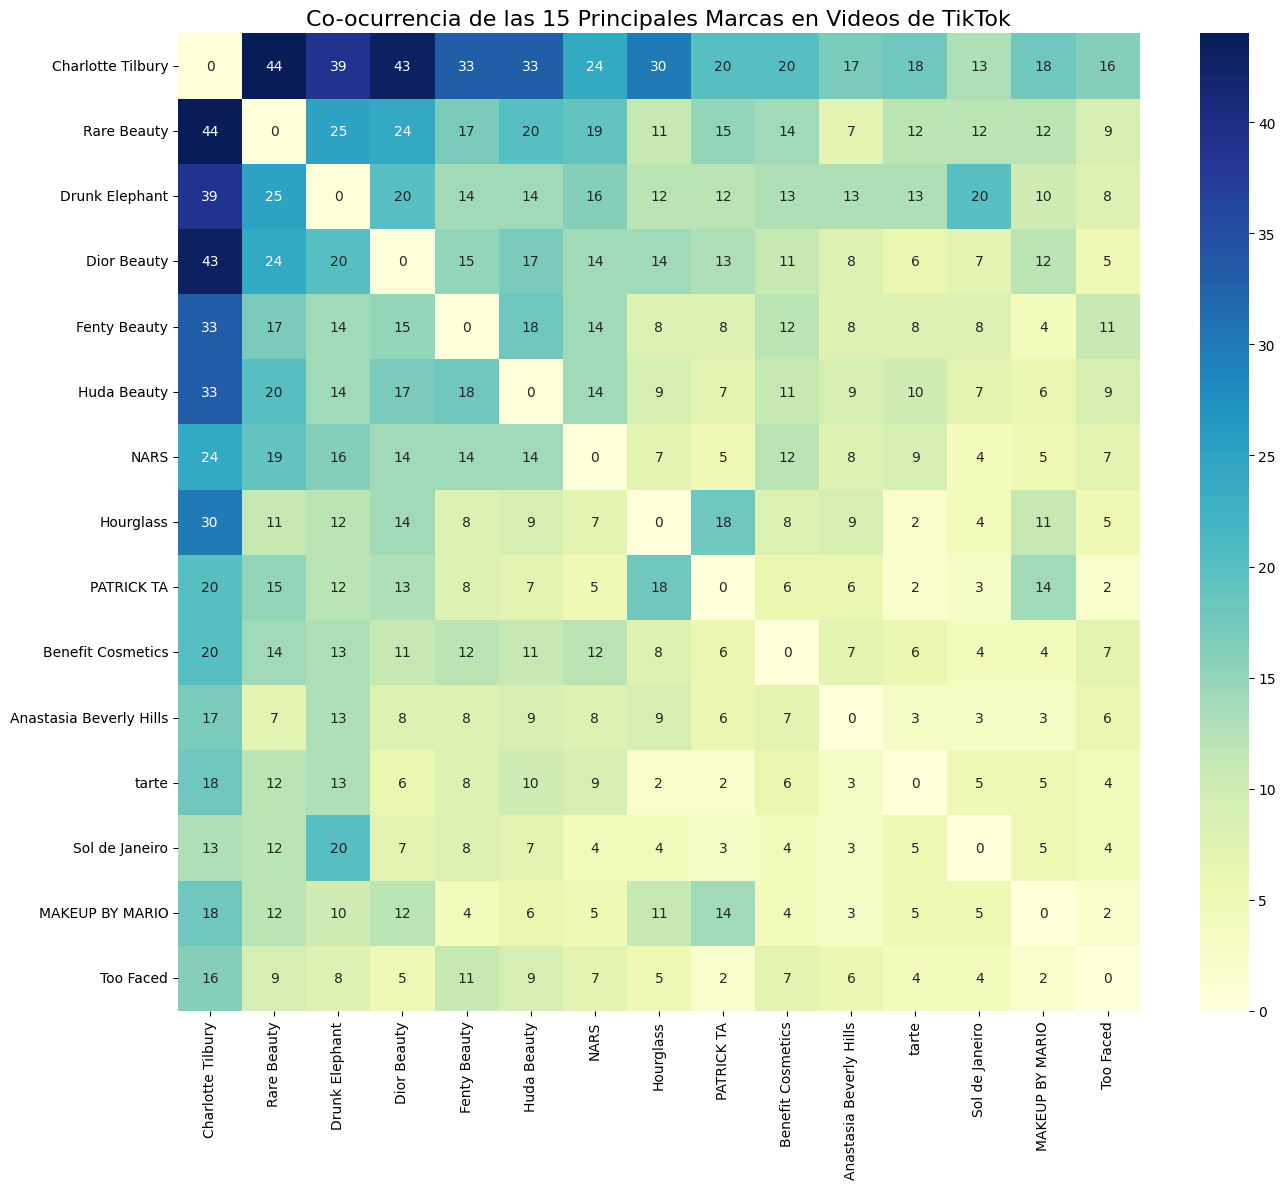

In [38]:
# Celda 11: Visualizar matriz de co-ocurrencia para las primeras 15 marcas (el mapa completo sería demasiado grande)
plt.figure(figsize=(14, 12))
top15_brands = brand_freq_df.head(15)['Brand'].tolist()
sns.heatmap(cooccurrence_df.loc[top15_brands, top15_brands], annot=True, cmap="YlGnBu", fmt='g')
plt.title('Co-ocurrencia de las 15 Principales Marcas en Videos de TikTok', fontsize=16)
plt.tight_layout()
heatmap_file = os.path.join(results_dir, "brands_cooccurrence_heatmap.png")
plt.savefig(heatmap_file, dpi=300)
print(f"Mapa de calor guardado en: {heatmap_file}")

In [39]:
# Celda 12: Guardar todos los resultados en un único archivo Excel
excel_results_file = os.path.join(results_dir, "market_basket_analysis_results.xlsx")
with pd.ExcelWriter(excel_results_file, engine='openpyxl') as writer:
    # Hoja 1: Frecuencia de marcas
    brand_freq_df = pd.DataFrame(brand_counts.items(), columns=['Brand', 'Frequency'])
    brand_freq_df['Support'] = brand_freq_df['Frequency'] / len(normalized_transactions)
    brand_freq_df['Percentage'] = brand_freq_df['Support'] * 100
    brand_freq_df = brand_freq_df.sort_values('Frequency', ascending=False)
    brand_freq_df.to_excel(writer, sheet_name='Brand_Frequencies', index=False)
    
    # Hoja 2: Itemsets frecuentes
    if frequent_itemsets is not None and len(frequent_itemsets) > 0:
        # Convertir los frozensets a strings para guardar
        frequent_itemsets_df = frequent_itemsets.copy()
        frequent_itemsets_df['itemsets_str'] = frequent_itemsets_df['itemsets'].apply(lambda x: ', '.join(list(x)))
        frequent_itemsets_df['itemset_size'] = frequent_itemsets_df['itemsets'].apply(len)
        frequent_itemsets_df['transactions_count'] = (frequent_itemsets_df['support'] * len(normalized_transactions)).astype(int)
        frequent_itemsets_df = frequent_itemsets_df.sort_values(['itemset_size', 'support'], ascending=[True, False])
        
        # Reorganizar columnas para mejor legibilidad
        frequent_itemsets_df.to_excel(writer, sheet_name='Frequent_Itemsets', index=False)
    
    # Hoja 3-5: Reglas de asociación (solo si hay reglas generadas)
    if rules is not None and len(rules) > 0:
        try:
            # Convertir frozensets a strings para guardar
            rules_df = rules.copy()
            rules_df['antecedents_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
            rules_df['consequents_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
            rules_df['transactions_count'] = (rules_df['support'] * len(normalized_transactions)).astype(int)
            
            # Añadir columnas solo si existen
            if 'confidence' in rules_df.columns:
                rules_df['confidence_pct'] = rules_df['confidence'] * 100
            
            rules_df.to_excel(writer, sheet_name='Association_Rules', index=False)
            
            # Hoja 4: Top reglas por lift (si existe la columna lift)
            if 'lift' in rules_df.columns:
                top_rules = rules_df.sort_values('lift', ascending=False).head(30).copy()
                top_rules.to_excel(writer, sheet_name='Top_Rules_by_Lift', index=False)
            
            # Hoja 5: Top reglas por confianza (si existe la columna confidence)
            if 'confidence' in rules_df.columns:
                top_conf_rules = rules_df.sort_values('confidence', ascending=False).head(30).copy()
                top_conf_rules.to_excel(writer, sheet_name='Top_Rules_by_Confidence', index=False)
        except Exception as e:
            print(f"Error al guardar las reglas en Excel: {e}")
            # Crear una hoja con mensaje informativo
            pd.DataFrame({'Mensaje': ['No se pudieron procesar las reglas de asociación correctamente']}).to_excel(
                writer, sheet_name='Reglas_Info', index=False)
    else:
        # Si no hay reglas, crear una hoja con mensaje informativo
        pd.DataFrame({'Mensaje': ['No se generaron reglas de asociación']}).to_excel(
            writer, sheet_name='Reglas_Info', index=False)
    
    # Hoja 6: Matriz de co-ocurrencia (todas las marcas son demasiadas, usar top 50)
    top50_brands_df = brand_freq_df.head(50)
    top50_brands_list = top50_brands_df['Brand'].tolist()
    cooccurrence_df_top50 = cooccurrence_df.loc[top50_brands_list, top50_brands_list]
    cooccurrence_df_top50.to_excel(writer, sheet_name='Cooccurrence_Matrix_Top50')
    
    # Hoja 7: Matriz de co-ocurrencia completa en una hoja separada
    cooccurrence_df.to_excel(writer, sheet_name='Cooccurrence_Matrix_Full')
    
    # Hoja 8: Guía de métricas MBA
    metrics_explanation = {
        'Métrica': [
            'Support (Soporte)', 
            'Confidence (Confianza)', 
            'Lift',
            'Leverage',
            'Conviction'
        ],
        'Explicación': [
            'Proporción de transacciones que contienen tanto el antecedente como el consecuente. Indica la frecuencia de la regla.',
            'Probabilidad condicional de que ocurra el consecuente dado el antecedente. Mide la fuerza de la implicación.',
            'Ratio entre la probabilidad observada y la esperada si los ítems fueran independientes. Lift > 1 indica asociación positiva.',
            'Diferencia entre la probabilidad observada y la esperada. Valores positivos indican asociación positiva.',
            'Mide cuánto depende el consecuente del antecedente. Valores altos indican dependencia fuerte.'
        ],
        'Fórmula': [
            'support(A→B) = P(A ∩ B)',
            'confidence(A→B) = P(B|A) = support(A→B) / support(A)',
            'lift(A→B) = confidence(A→B) / support(B)',
            'leverage(A→B) = support(A→B) - support(A) × support(B)',
            'conviction(A→B) = (1 - support(B)) / (1 - confidence(A→B))'
        ],
        'Interpretación': [
            'Un soporte alto indica que la regla es frecuente en los datos.',
            'Una confianza alta indica que la regla tiene alta precisión.',
            'Lift > 1: Asociación positiva, Lift < 1: Asociación negativa, Lift = 1: Independencia.',
            'Valores positivos indican que los items aparecen juntos más de lo esperado.',
            'Valores altos indican reglas más interesantes.'
        ]
    }
    
    pd.DataFrame(metrics_explanation).to_excel(writer, sheet_name='MBA_Metrics_Guide', index=False)

print(f"\nTodos los resultados del análisis han sido guardados en: {excel_results_file}")


Todos los resultados del análisis han sido guardados en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\market_basket_analysis_results.xlsx


In [40]:
# Celda 13: Calcular matriz de lift para todas las marcas
# Calcular lift entre pares de marcas
lift_matrix = np.zeros((len(all_brands_list), len(all_brands_list)))

for i, brand1 in enumerate(all_brands_list):
    for j, brand2 in enumerate(all_brands_list):
        if i != j:
            # Contar apariciones individuales
            count1 = brand_counts.get(brand1, 0)
            count2 = brand_counts.get(brand2, 0)
            
            # Contar co-ocurrencias
            cooccurrence = 0
            for transaction in normalized_transactions:
                if brand1 in transaction and brand2 in transaction:
                    cooccurrence += 1
            
            # Calcular lift (evitar división por cero)
            if count1 > 0 and count2 > 0:
                support1 = count1 / len(normalized_transactions)
                support2 = count2 / len(normalized_transactions)
                support_pair = cooccurrence / len(normalized_transactions)
                lift_value = support_pair / (support1 * support2) if (support1 * support2) > 0 else 0
                lift_matrix[i, j] = lift_value

# Crear DataFrame para el mapa de calor de lift
lift_df = pd.DataFrame(lift_matrix, index=all_brands_list, columns=all_brands_list)

# Guardar matriz de lift
lift_file = os.path.join(results_dir, "brand_lift_matrix.csv")
lift_df.to_csv(lift_file)
print(f"Matriz de lift guardada en: {lift_file}")

# Añadir matriz de lift al Excel de resultados
with pd.ExcelWriter(excel_results_file, mode='a', engine='openpyxl') as writer:
    # Guardar matriz de lift de top 50 marcas
    lift_df_top50 = lift_df.loc[top50_brands_list, top50_brands_list]
    lift_df_top50.to_excel(writer, sheet_name='Lift_Matrix_Top50')
    
    # Guardar matriz de lift completa
    lift_df.to_excel(writer, sheet_name='Lift_Matrix_Full')

Matriz de lift guardada en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\brand_lift_matrix.csv


Mapa de calor de lift guardado en: C:\Users\sandr\Documents\scrp_tiktok_tfg\analysis\nlp\MBA\results\brands_lift_heatmap.png
Análisis de Market Basket completado con éxito. Todos los resultados se han guardado en el directorio de resultados.


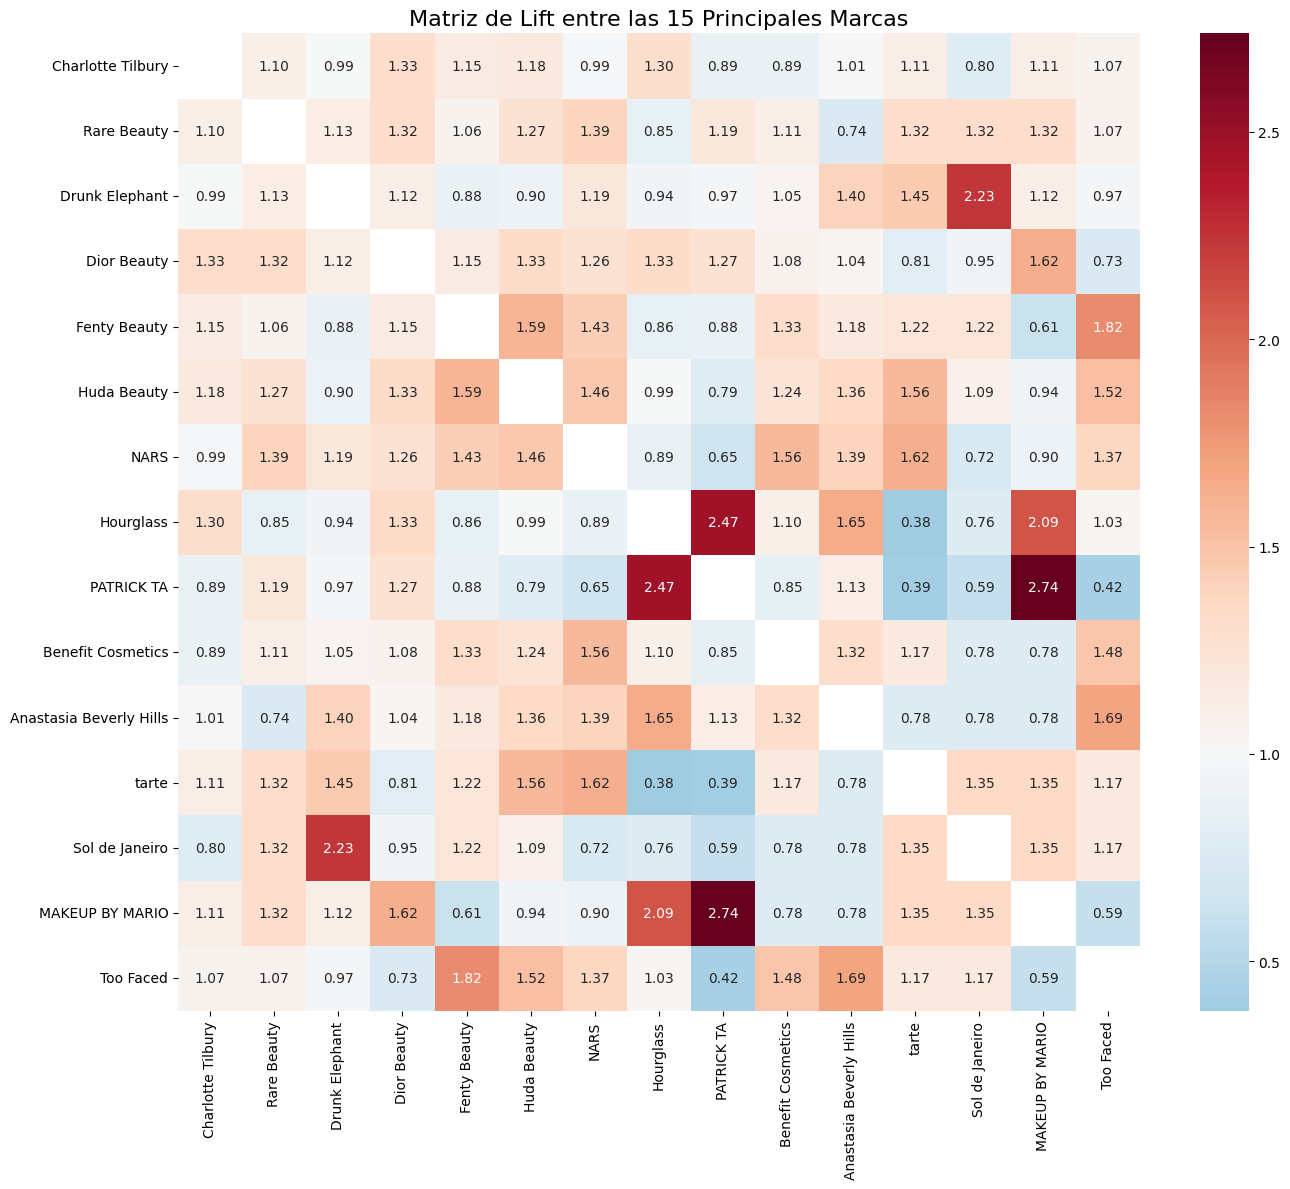

In [41]:
# Celda 14: Visualizar matriz de lift para las 15 marcas principales
plt.figure(figsize=(14, 12))
mask = np.zeros_like(lift_df.loc[top15_brands, top15_brands])
np.fill_diagonal(mask, 1)  # Marcar la diagonal principal para no mostrarla
sns.heatmap(lift_df.loc[top15_brands, top15_brands], annot=True, cmap="RdBu_r", center=1, mask=mask, fmt='.2f')
plt.title('Matriz de Lift entre las 15 Principales Marcas', fontsize=16)
plt.tight_layout()
lift_heatmap_file = os.path.join(results_dir, "brands_lift_heatmap.png")
plt.savefig(lift_heatmap_file, dpi=300)
print(f"Mapa de calor de lift guardado en: {lift_heatmap_file}")

print("Análisis de Market Basket completado con éxito. Todos los resultados se han guardado en el directorio de resultados.")

## 📊 Diferencia entre Matriz de Co-ocurrencia y Matriz de Lift

En el análisis de asociación entre pares de marcas, es común trabajar con **matrices de co-ocurrencia** y **matrices de lift**. Aunque ambas están relacionadas con la asociación entre marcas, representan medidas distintas y tienen interpretaciones diferentes.

---

### Matriz de Co-ocurrencia  
- ✅ **Mide frecuencia absoluta** → Indica cuántas veces aparecen juntas dos marcas.  
- ✅ Es una **medida de conteo simple** → No tiene en cuenta la popularidad individual de cada marca.  
- ✅ Los valores son **números enteros** → Directamente basados en la frecuencia de aparición conjunta.  

👉 **Ejemplo:** Si las marcas A y B aparecen juntas en 100 videos, el valor de co-ocurrencia será 100.

---

### Matriz de Lift  
- ✅ **Mide asociación relativa** → Ajusta la co-ocurrencia en función de la popularidad individual de cada marca.  
- ✅ La fórmula es:  
\[
\text{lift}(A, B) = \frac{P(A, B)}{P(A) \times P(B)}
\]
donde:  
- \(P(A, B)\) = Probabilidad de que A y B aparezcan juntas  
- \(P(A)\) = Probabilidad de que aparezca A  
- \(P(B)\) = Probabilidad de que aparezca B  

- ✅ **Interpretación de valores:**
  - **Lift > 1** → Asociación positiva (más probable que aparezcan juntas de lo esperado).  
  - **Lift = 1** → Independencia (sin asociación).  
  - **Lift < 1** → Asociación negativa (menos probable que aparezcan juntas de lo esperado).  

 **Ejemplo:** Si las marcas A y B aparecen juntas más de lo esperado considerando su popularidad individual, el lift será mayor a 1.

---

### Ejemplo para entender la diferencia  
Supongamos dos casos:

1. **Caso 1:**  
- Marca A → Aparece en el **80%** de los videos.  
- Marca B → Aparece en el **70%** de los videos.  
- A y B aparecen juntas en el **60%** de los videos.  

➡️ **Lift(A, B):**  
\[
\frac{0.60}{0.80 \times 0.70} = \frac{0.60}{0.56} = 1.07 \quad (\text{asociación ligeramente positiva})
\]

2. **Caso 2:**  
- Marca C → Aparece en el **10%** de los videos.  
- Marca D → Aparece en el **5%** de los videos.  
- C y D aparecen juntas en el **4%** de los videos.  

➡️ **Lift(C, D):**  
\[
\frac{0.04}{0.10 \times 0.05} = \frac{0.04}{0.005} = 8.0 \quad (\text{asociación muy fuerte})
\]

🔎 **Interpretación:**  
- La **co-ocurrencia** mostraría que A y B aparecen juntas más veces (valor absoluto más alto).  
- El **lift** indicaría que C y D tienen una asociación más fuerte porque aparecen juntas mucho más de lo esperado considerando su popularidad individual.  

---

### Conclusión  
✅ La **matriz de co-ocurrencia** mide datos brutos sobre frecuencia conjunta.  
✅ La **matriz de lift** ofrece una medida estandarizada de asociación que compensa la popularidad individual de las marcas.  
➡️ **Ambas matrices son complementarias** y ofrecen una visión más completa de las relaciones entre marcas en tus datos.  
